In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [11]:
# Load the data
config = pd.read_csv('experiments/models/dataset_quality/experiment_config.csv')
results = pd.read_csv('experiments/results/dataset_quality.csv')

In [12]:
results['experiment'] = results['model_id'].apply(lambda x: x.split('_')[-1])
results['experiment'] = results['experiment'].astype(int)

In [13]:
# Merge the results and config DataFrames on the 'experiment' column
df = pd.merge(results, config, on='experiment', suffixes=('_results', '_config'))

In [14]:
df['model'] = df['model_id'].apply(lambda x: x.split('_')[0])
# Create a new column 'dataset_quantity' as the product of 'dataset_size', 'train_size', and 'val_size'
df['train_size'] = df['train_size']*df['dataset_size']
df['val_size'] = df['val_size']*df['dataset_size']
df['dataset_size'] = df['train_size']+df['val_size']

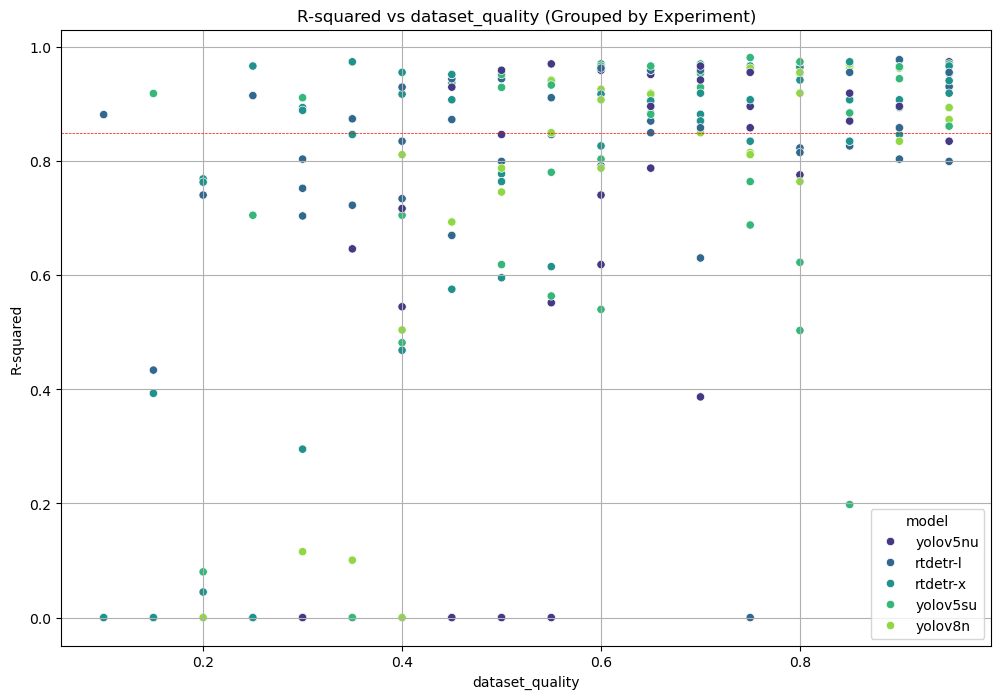

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Filter the DataFrame with model == 'yolov5lu'
#filtered_df = df[df['model'] == 'yolov5su']
# Drop rows with NaN values in 'r_squared'
filtered_df = df.dropna(subset=['r_squared'])# Group by 'experiment' and select the observation with the highest R-squared value
filtered_df = filtered_df.loc[filtered_df.groupby('experiment')['r_squared'].idxmax()]

# set r-squared <0 to 0
filtered_df.loc[filtered_df['r_squared'] < 0, 'r_squared'] = 0

# Sort by dataset size
filtered_df = filtered_df.sort_values(by='dataset_quality')

# Create a scatter plot with 'dataset_size' on the x-axis and 'r_squared' on the y-axis
plt.figure(figsize=(12, 8))
sns.scatterplot(data=filtered_df, x='dataset_quality', y='r_squared', hue='model', palette='viridis')

# Plot a red line at y = 0.85
plt.axhline(y=0.85, color='red', linestyle='--', linewidth=0.5)

plt.xlabel('dataset_quality')
plt.ylabel('R-squared')
plt.title('R-squared vs dataset_quality (Grouped by Experiment)')
plt.grid(True)

plt.show()

In [9]:
df['model'].unique()

array(['yolov5nu', 'yolov5su', 'yolov8n', 'rtdetr-l', 'rtdetr-x'],
      dtype=object)

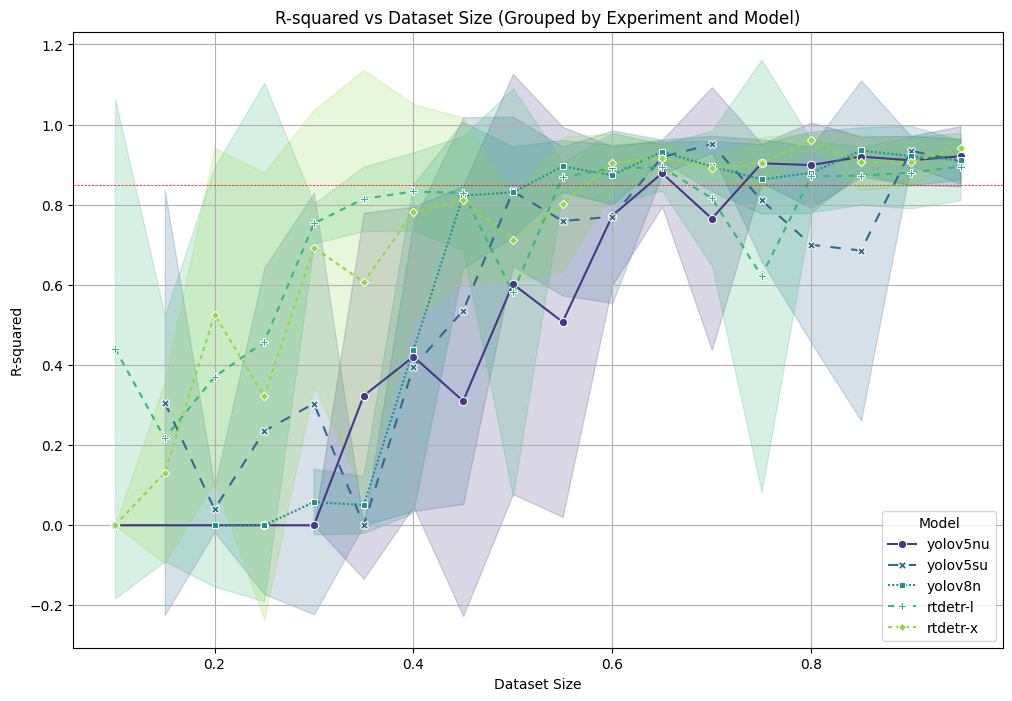

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Initialize the filtered DataFrame
filtered_df = df.dropna(subset=['r_squared'])# Group by 'experiment' and select the observation with the highest R-squared value

# Group by 'experiment' and 'model' and select the observation with the highest R-squared value
filtered_df = filtered_df.loc[filtered_df.groupby(['experiment', 'model'])['r_squared'].idxmax()]

# Set r-squared <0 to 0
filtered_df = filtered_df[filtered_df['r_squared'] >= -1]

# Sort by dataset size
filtered_df = filtered_df.sort_values(by='dataset_quality')

# Define custom colors and linestyles for each model
palette = sns.color_palette("viridis", 5)  # Update palette to have 5 colors
linestyles = {'yolov5nu': '', 'yolov5su': (5, 5), 'yolov8n': (1, 1), 'rtdetr-l': (3, 3), 'rtdetr-x': (2, 2)}  # Update dashes to have 5 styles

# Create a line plot with 'dataset_size' on the x-axis and mean 'r_squared' on the y-axis, grouped by 'model'
plt.figure(figsize=(12, 8))
sns.lineplot(x='dataset_quality', y='r_squared', hue='model', style='model', data=filtered_df, 
             errorbar='sd', estimator='mean', markers=True, palette=palette, dashes=linestyles, 
             hue_order=['yolov5nu', 'yolov5su', 'yolov8n', 'rtdetr-l', 'rtdetr-x'], 
             style_order=['yolov5nu', 'yolov5su', 'yolov8n', 'rtdetr-l', 'rtdetr-x'])

# Plot a red line at y = 0.85
plt.axhline(y=0.85, color='red', linestyle='--', linewidth=0.5)

plt.xlabel('Dataset Size')
plt.ylabel('R-squared')
plt.title('R-squared vs Dataset Size (Grouped by Experiment and Model)')
plt.grid(True)
plt.legend(title='Model')

plt.show()

/tmp/ipykernel_63154/4154497033.py:26: UserWarning: The palette list has more values (5) than needed (1), which may not be intended.
  sns.lineplot(x='dataset_quality', y='r_squared', hue='model', style='model', data=filtered_df[filtered_df['model'] == model],
/tmp/ipykernel_63154/4154497033.py:26: UserWarning: The palette list has more values (5) than needed (1), which may not be intended.
  sns.lineplot(x='dataset_quality', y='r_squared', hue='model', style='model', data=filtered_df[filtered_df['model'] == model],
/tmp/ipykernel_63154/4154497033.py:26: UserWarning: The palette list has more values (5) than needed (1), which may not be intended.
  sns.lineplot(x='dataset_quality', y='r_squared', hue='model', style='model', data=filtered_df[filtered_df['model'] == model],
/tmp/ipykernel_63154/4154497033.py:26: UserWarning: The palette list has more values (5) than needed (1), which may not be intended.
  sns.lineplot(x='dataset_quality', y='r_squared', hue='model', style='model', data=

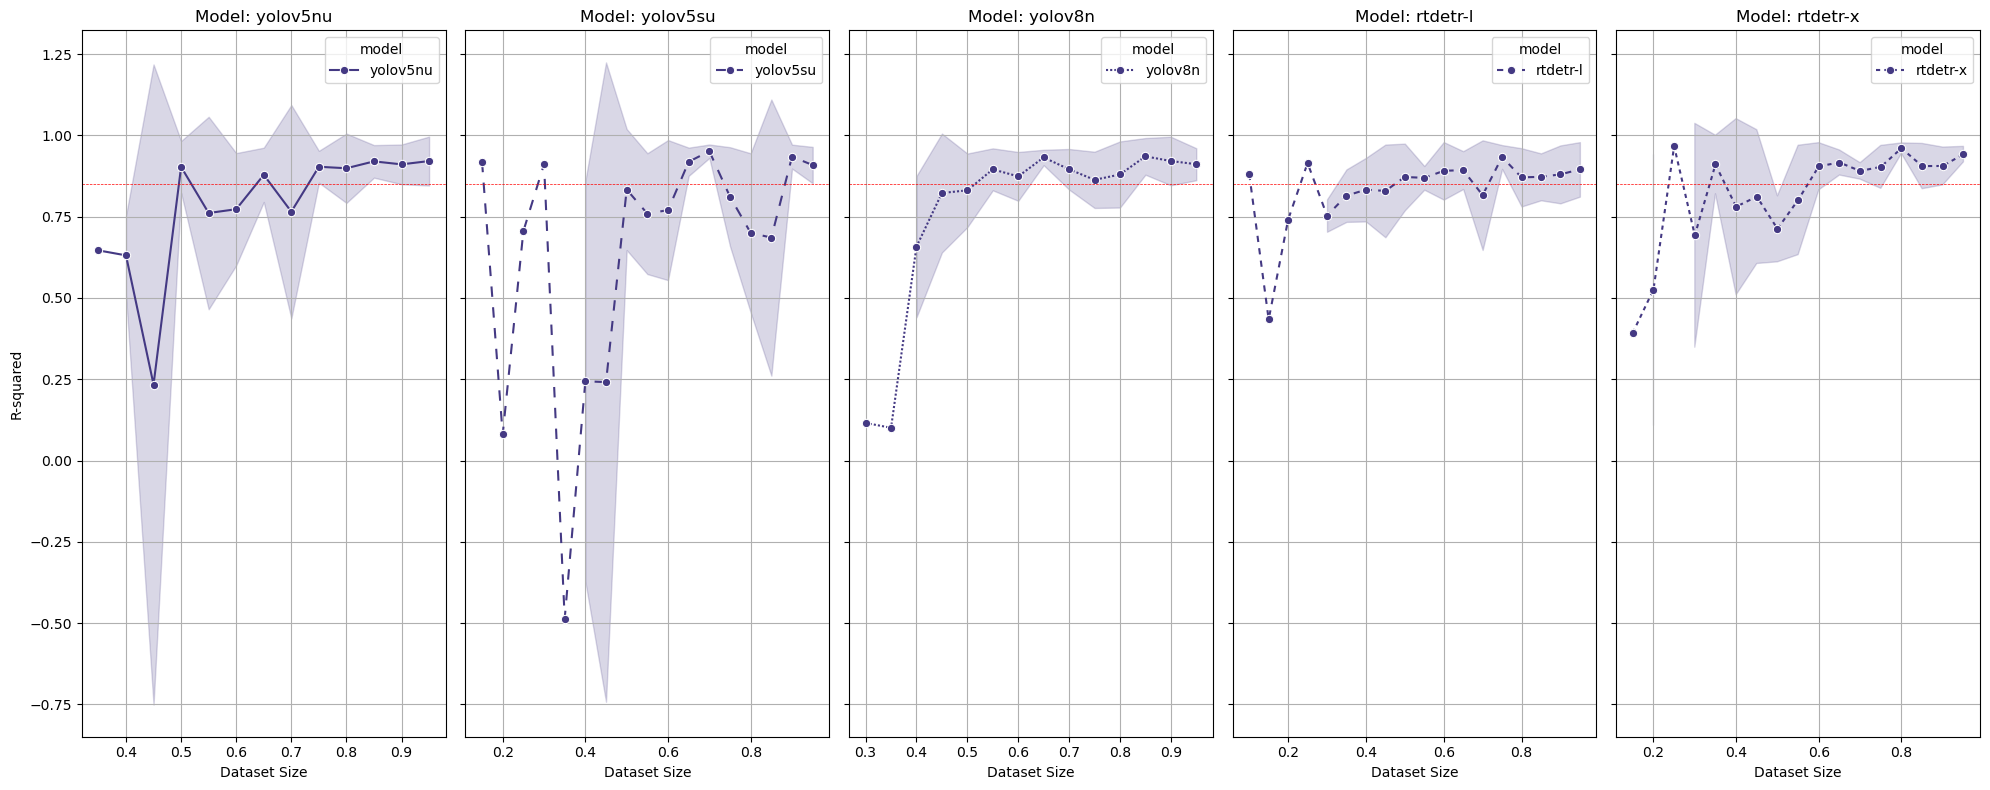

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Initialize the filtered DataFrame
filtered_df = df.dropna(subset=['r_squared'])

# Group by 'experiment' and 'model' and select the observation with the highest R-squared value
filtered_df = filtered_df.loc[filtered_df.groupby(['experiment', 'model'])['r_squared'].idxmax()]

# Set r-squared <0 to 0
filtered_df = filtered_df[filtered_df['r_squared'] >= -1]

# Sort by dataset size
filtered_df = filtered_df.sort_values(by='dataset_quality')

# Define custom colors and linestyles for each model
palette = sns.color_palette("viridis", 5)  # Update palette to have 5 colors
linestyles = {'yolov5nu': '', 'yolov5su': (5, 5), 'yolov8n': (1, 1), 'rtdetr-l': (3, 3), 'rtdetr-x': (2, 2)}  # Update dashes to have 5 styles

# Create subplots
models = ['yolov5nu', 'yolov5su', 'yolov8n', 'rtdetr-l', 'rtdetr-x']
fig, axes = plt.subplots(1, len(models), figsize=(20, 8), sharey=True)

for ax, model in zip(axes, models):
    sns.lineplot(x='dataset_quality', y='r_squared', hue='model', style='model', data=filtered_df[filtered_df['model'] == model], 
                 errorbar='sd', estimator='mean', markers=True, palette=palette, dashes=linestyles, 
                 hue_order=[model], style_order=[model], ax=ax)
    ax.axhline(y=0.85, color='red', linestyle='--', linewidth=0.5)
    ax.set_title(f'Model: {model}')
    ax.set_xlabel('Dataset Size')
    ax.set_ylabel('R-squared')
    ax.grid(True)

plt.tight_layout()
plt.show()

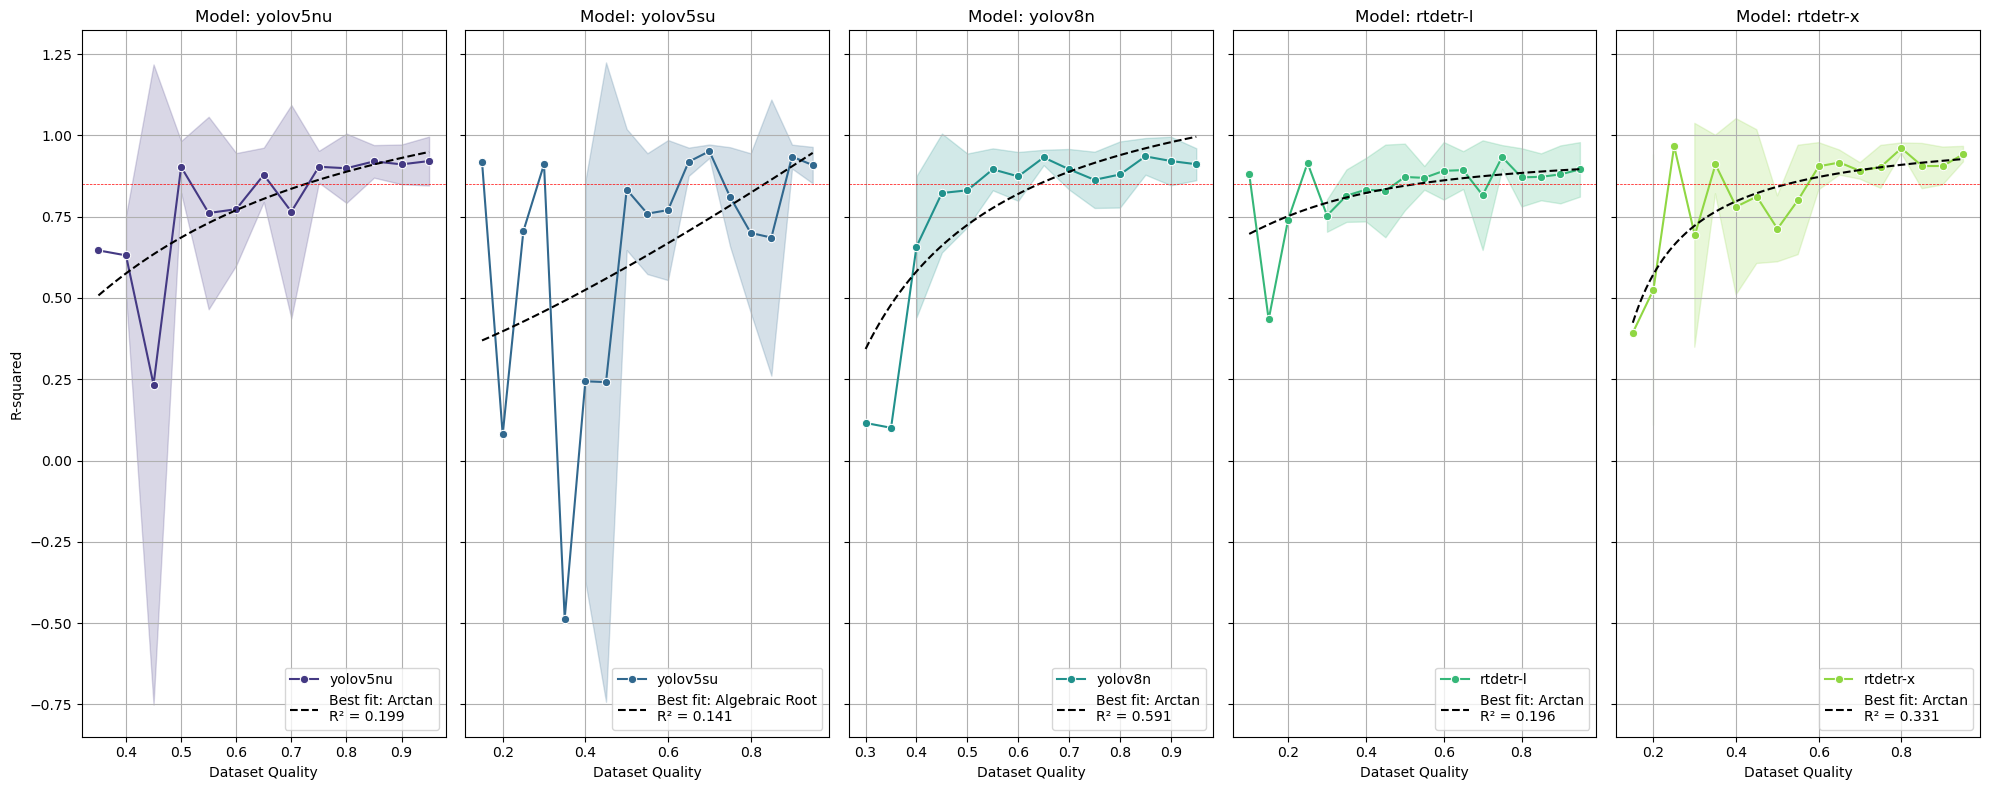

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score

# Initialize the filtered DataFrame
filtered_df = df.dropna(subset=['r_squared'])

# Group by 'experiment' and 'model' and select the observation with the highest R-squared value
filtered_df = filtered_df.loc[filtered_df.groupby(['experiment', 'model'])['r_squared'].idxmax()]

# Set r-squared <0 to 0
filtered_df = filtered_df[filtered_df['r_squared'] >= -1]

# Sort by dataset quality
filtered_df = filtered_df.sort_values(by='dataset_quality')

# Define fitting functions
def log_func(x, a, b):
    return a * np.log(x) + b

def arctan_func(x, a, b, c):
    return a * np.arctan(b * x) + c

def root_func(x, a, b, c):
    return a * np.power(x, 1/b) + c

# Define custom colors for each model
palette = sns.color_palette("viridis", 5)
model_colors = dict(zip(['yolov5nu', 'yolov5su', 'yolov8n', 'rtdetr-l', 'rtdetr-x'], palette))

# Create subplots
models = ['yolov5nu', 'yolov5su', 'yolov8n', 'rtdetr-l', 'rtdetr-x']
fig, axes = plt.subplots(1, len(models), figsize=(20, 8), sharey=True)

for ax, model in zip(axes, models):
    # Filter to single model
    model_data = filtered_df[filtered_df['model'] == model]
    
    # Plot original data points - FIXED: removed hue and style parameters
    sns.lineplot(
        x='dataset_quality', 
        y='r_squared', 
        data=model_data,
        errorbar='sd', 
        estimator='mean', 
        marker='o',
        color=model_colors[model],
        ax=ax,
        label=model
    )
    
    # Fit functions for r_squared vs dataset_quality
    x_data = model_data['dataset_quality']
    y_data = model_data['r_squared']
    
    # Skip fitting if we have too few data points
    if len(x_data) < 3:
        ax.set_title(f'Model: {model} (insufficient data for fitting)')
        continue
        
    x_fit = np.linspace(x_data.min(), x_data.max(), 100)
    
    # Initialize variables to track best fit
    best_fit = None
    best_score = -np.inf
    best_name = ""
    
    # Try logarithmic fit
    try:
        popt_log, _ = curve_fit(log_func, x_data, y_data)
        y_fit_log = log_func(x_fit, *popt_log)
        r2_log = r2_score(y_data, log_func(x_data, *popt_log))
        if r2_log > best_score:
            best_fit = y_fit_log
            best_score = r2_log
            best_name = "Logarithmic"
    except Exception as e:
        r2_log = -np.inf
    
    # Try arctan fit
    try:
        popt_arctan, _ = curve_fit(arctan_func, x_data, y_data, p0=[1, 1, 0])
        y_fit_arctan = arctan_func(x_fit, *popt_arctan)
        r2_arctan = r2_score(y_data, arctan_func(x_data, *popt_arctan))
        if r2_arctan > best_score:
            best_fit = y_fit_arctan
            best_score = r2_arctan
            best_name = "Arctan"
    except Exception as e:
        r2_arctan = -np.inf
    
    # Try root fit
    try:
        p0 = [1, 2, 0]  # Initial parameter guess
        popt_root, _ = curve_fit(root_func, x_data, y_data, p0=p0)
        y_fit_root = root_func(x_fit, *popt_root)
        r2_root = r2_score(y_data, root_func(x_data, *popt_root))
        if r2_root > best_score:
            best_fit = y_fit_root
            best_score = r2_root
            best_name = "Algebraic Root"
    except Exception as e:
        r2_root = -np.inf
    
    # Plot the best fit
    if best_fit is not None:
        ax.plot(x_fit, best_fit, linestyle='--', color='black', 
                label=f'Best fit: {best_name}\nR² = {best_score:.3f}')
    
    ax.axhline(y=0.85, color='red', linestyle='--', linewidth=0.5)
    ax.set_title(f'Model: {model}')
    ax.set_xlabel('Dataset Quality')
    ax.set_ylabel('R-squared')
    ax.grid(True)
    ax.legend(loc='lower right')

plt.tight_layout()
plt.savefig('MDPI_template/Plots/r2_vs_dataset_quality.pdf', format='pdf')
# plt.show()

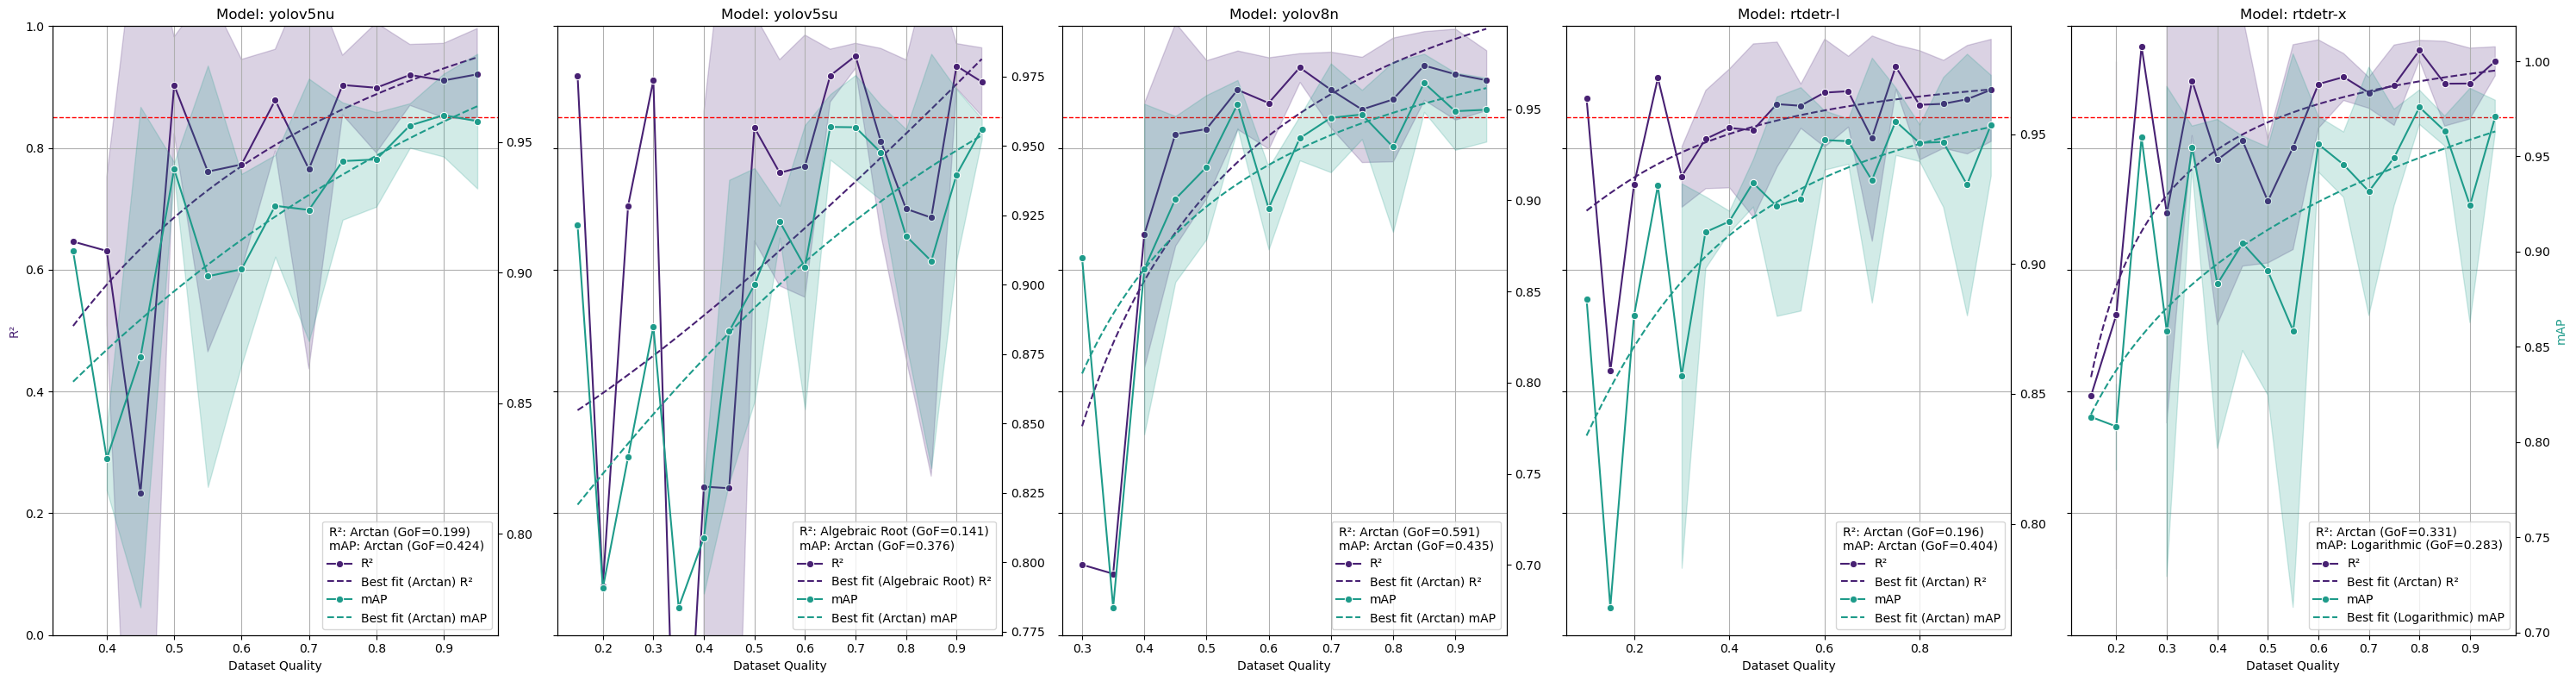

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score

# Initialize the filtered DataFrame
filtered_df = df.dropna(subset=['r_squared'])

# Group by 'experiment' and 'model' and select the observation with the highest R-squared value
filtered_df = filtered_df.loc[filtered_df.groupby(['experiment', 'model'])['r_squared'].idxmax()]

# Set r-squared <0 to 0
filtered_df = filtered_df[filtered_df['r_squared'] >= -1]

# Sort by dataset quality
filtered_df = filtered_df.sort_values(by='dataset_quality')

# Define fitting functions
def log_func(x, a, b):
    return a * np.log(x) + b

def arctan_func(x, a, b, c):
    return a * np.arctan(b * x) + c

def root_func(x, a, b, c):
    return a * np.power(x, 1/b) + c

# Define custom colors for each model and metric
palette = sns.color_palette("viridis", 10)
model_colors = dict(zip(['yolov5nu', 'yolov5su', 'yolov8n', 'rtdetr-l', 'rtdetr-x'], palette[::2]))
metric_colors = {'r_squared': palette[0], 'ap_iou_50': palette[5]}

# Create subplots
models = ['yolov5nu', 'yolov5su', 'yolov8n', 'rtdetr-l', 'rtdetr-x']
fig, axes = plt.subplots(1, len(models), figsize=(30, 8), sharey=True)

for i, (ax, model) in enumerate(zip(axes, models)):
    # Filter to single model
    model_data = filtered_df[filtered_df['model'] == model]
    
    # Plot r_squared
    sns.lineplot(
        x='dataset_quality', 
        y='r_squared', 
        data=model_data,
        errorbar='sd', 
        estimator='mean', 
        marker='o',
        color=metric_colors['r_squared'],
        ax=ax,
        label='R²',
        legend=False
    )
    
    # Fit functions for r_squared vs dataset_quality
    x_data = model_data['dataset_quality']
    y_data = model_data['r_squared']
    
    # Skip fitting if we have too few data points
    if len(x_data) < 3:
        ax.set_title(f'Model: {model} (insufficient data for fitting)')
        continue
        
    x_fit = np.linspace(x_data.min(), x_data.max(), 100)
    
    # Initialize variables to track best fit for r_squared
    best_r2_fit = None
    best_r2_score = -np.inf
    best_r2_name = ""
    
    # Try logarithmic fit for r_squared
    try:
        popt_log, _ = curve_fit(log_func, x_data, y_data)
        y_fit_log = log_func(x_fit, *popt_log)
        r2_log = r2_score(y_data, log_func(x_data, *popt_log))
        if r2_log > best_r2_score:
            best_r2_fit = y_fit_log
            best_r2_score = r2_log
            best_r2_name = "Logarithmic"
    except Exception as e:
        r2_log = -np.inf
    
    # Try arctan fit for r_squared
    try:
        popt_arctan, _ = curve_fit(arctan_func, x_data, y_data, p0=[1, 1, 0])
        y_fit_arctan = arctan_func(x_fit, *popt_arctan)
        r2_arctan = r2_score(y_data, arctan_func(x_data, *popt_arctan))
        if r2_arctan > best_r2_score:
            best_r2_fit = y_fit_arctan
            best_r2_score = r2_arctan
            best_r2_name = "Arctan"
    except Exception as e:
        r2_arctan = -np.inf
    
    # Try root fit for r_squared
    try:
        p0 = [1, 2, 0]  # Initial parameter guess
        popt_root, _ = curve_fit(root_func, x_data, y_data, p0=p0)
        y_fit_root = root_func(x_fit, *popt_root)
        r2_root = r2_score(y_data, root_func(x_data, *popt_root))
        if r2_root > best_r2_score:
            best_r2_fit = y_fit_root
            best_r2_score = r2_root
            best_r2_name = "Algebraic Root"
    except Exception as e:
        r2_root = -np.inf
    
    # Plot the best fit for r_squared
    ax.plot(x_fit, best_r2_fit, color=metric_colors['r_squared'], linestyle='--', 
            label=f'Best fit ({best_r2_name}) R²')
    
    # Create a twin Axes sharing the x-axis
    ax2 = ax.twinx()
    
    # Plot ap_iou_50
    sns.lineplot(
        x='dataset_quality', 
        y='ap_iou_50', 
        data=model_data,
        errorbar='sd', 
        estimator='mean', 
        marker='o',
        color=metric_colors['ap_iou_50'],
        ax=ax2,
        label='mAP',
        legend=False
    )
    
    # Fit functions for ap_iou_50 vs dataset_quality
    y_data_ap = model_data['ap_iou_50']
    
    # Initialize variables to track best fit for ap_iou_50
    best_ap_fit = None
    best_ap_score = -np.inf
    best_ap_name = ""
    
    # Try logarithmic fit for ap_iou_50
    try:
        popt_log_ap, _ = curve_fit(log_func, x_data, y_data_ap)
        y_fit_log_ap = log_func(x_fit, *popt_log_ap)
        r2_log_ap = r2_score(y_data_ap, log_func(x_data, *popt_log_ap))
        if r2_log_ap > best_ap_score:
            best_ap_fit = y_fit_log_ap
            best_ap_score = r2_log_ap
            best_ap_name = "Logarithmic"
    except Exception as e:
        r2_log_ap = -np.inf
    
    # Try arctan fit for ap_iou_50
    try:
        popt_arctan_ap, _ = curve_fit(arctan_func, x_data, y_data_ap)
        y_fit_arctan_ap = arctan_func(x_fit, *popt_arctan_ap)
        r2_arctan_ap = r2_score(y_data_ap, arctan_func(x_data, *popt_arctan_ap))
        if r2_arctan_ap > best_ap_score:
            best_ap_fit = y_fit_arctan_ap
            best_ap_score = r2_arctan_ap
            best_ap_name = "Arctan"
    except Exception as e:
        r2_arctan_ap = -np.inf
    
    # Try root fit for ap_iou_50
    try:
        popt_root_ap, _ = curve_fit(root_func, x_data, y_data_ap, p0=[1, 2, 0])
        y_fit_root_ap = root_func(x_fit, *popt_root_ap)
        r2_root_ap = r2_score(y_data_ap, root_func(x_data, *popt_root_ap))
        if r2_root_ap > best_ap_score:
            best_ap_fit = y_fit_root_ap
            best_ap_score = r2_root_ap
            best_ap_name = "Algebraic Root"
    except Exception as e:
        r2_root_ap = -np.inf
    
    # Plot the best fit for ap_iou_50
    ax2.plot(x_fit, best_ap_fit, color=metric_colors['ap_iou_50'], linestyle='--', 
             label=f'Best fit ({best_ap_name}) mAP')
    
    ax.axhline(y=0.85, color='red', linestyle='--', linewidth=1)
    ax.set_title(f'Model: {model}')
    ax.set_xlabel('Dataset Quality')
    ax.set_ylabel('R²', color=metric_colors['r_squared'])
    ax.set_ylim(0, 1)
    ax.grid(True)
    
    # Combine legends
    lines, labels = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    combined_lines = lines + lines2
    combined_labels = labels + labels2
    
    # Include best fit function name and R-squared in the legend title
    combined_title = f'R²: {best_r2_name} (GoF={best_r2_score:.3f})\nmAP: {best_ap_name} (GoF={best_ap_score:.3f})'
    ax2.legend(combined_lines, combined_labels, title=combined_title, loc='lower right')
    
    if i == len(models) - 1:
        ax2.set_ylabel('mAP', color=metric_colors['ap_iou_50'])
    else:
        ax2.set_ylabel('')

plt.tight_layout()
plt.savefig('MDPI_template/Plots/r2_ap_vs_dataset_quality.pdf', format='pdf')
# plt.show()